# HealthConnect Clinic: No-Show Prediction
### Week 6 Data Science Track: Model Improvement, Error Analysis & Validation
### AnalystLab Africa Experience Lab

**Prepared by:** Data Science Intern
**Project:** HealthConnect Clinic Experience Lab
**Track:** Data Science

Week 5 established a baseline logistic regression model (63.4% accuracy, ROC-AUC 0.68 on a single train/test split) and was explicit that the goal at that stage was a *reliable baseline*, not a finished model.

Week 6 does not repeat that baseline. Instead it: analyses where the Week 5 model actually fails, incorporates validated findings handed over by the Data Analytics track as engineered interaction features, evaluates everything under proper cross-validation rather than a single split, compares three modelling approaches, and settles on a candidate model to carry into Week 7 testing.

## 1. Week 5 → Week 6 Transition

**Main Week 5 output:** A cleaned, modelling-ready dataset, five engineered features, a patient-grouped train/test split, and a logistic regression baseline outperforming both a majority-class and a rule-based baseline.

**Most important result:** Logistic regression reached 63.4% accuracy and ROC-AUC 0.68 on the held-out test set — `previous_no_shows` was the strongest risk-increasing factor, `no_show_rate_history` and `reminder_sent` the strongest protective factors.

**Main limitation discovered:** Only a single 80/20 split was evaluated, so there was no sense of how stable that performance actually is. The model also had no engineered interaction terms — each feature was treated independently.

**Track relevant to Week 6 work:** Data Analytics. Their Week 5/6 crosstab analysis validated and quantified two relationships the Week 5 model only had indirect access to: previous no-shows losing some of their risk when a reminder is sent, and no-show rate climbing steeply and steadily with booking lead time.

**What Week 6 improves, integrates and validates:**
- **Improve:** engineer explicit interaction features from the Data Analytics findings; replace the coarse lead-time flags with lead-time bands.
- **Integrate:** bring the Data Analytics track's validated crosstabs directly into the feature set, rather than re-deriving the same patterns independently.
- **Validate:** move from one split to 5-fold grouped cross-validation, and run a structured error analysis on the Week 5 baseline before making any changes.

## 2. Part 1 — Week 6 Integration Readiness

**A. Integration point**
- **Track worked with:** Data Analytics.
- **Output needed from that track:** Validated crosstab findings on how `previous_no_shows`, `reminder_sent`, `booking_lead_days`, and `distance_to_clinic_km` interact with the no-show outcome — specifically, exact no-show rates at each combination of previous no-shows × reminder status, booking lead-time bands, and distance × reminder status.
- **Output provided to that track:** Confirmation of which of these interactions the model actually finds informative once tested formally (see Section 6), so the Analytics track knows which of their findings are worth featuring prominently in HealthConnect-facing recommendations versus which look weaker under a predictive lens.
- **Why relevant:** The Analytics track's crosstabs are business-facing evidence of relationships; this track's job is to check whether those same relationships hold up as *predictive* features, and to translate them into a form a model can use directly (bins, interaction terms) instead of relying on the model to rediscover them from raw columns.

**B. Integration objective**
After this activity, the feature set should explicitly encode the two strongest cross-track findings (the previous-no-shows/reminder interaction and the lead-time relationship) as model inputs, and the resulting model should be evaluated against the Week 5 baseline under the same, more rigorous validation procedure — so any improvement (or lack of one) is attributable to the integration itself rather than to a lucky split.

**C. Evidence**
This notebook (updated feature set, error analysis, cross-validated model comparison), the Week 6 project summary, and the updated repository README constitute the integration evidence.

## 3. Data Analytics Findings Under Review

The Data Analytics track shared three crosstab findings ahead of Week 6. Each is re-checked against this track's cleaned dataset before being built into a feature, since a Week 6 requirement is to validate — not just accept — findings from another track.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay)

pd.set_option('display.max_columns', None)

df = pd.read_csv('HealthConnect_Appointment_Data_Cleaned.csv')
df['reminder_channel'] = df['reminder_channel'].fillna('None')
print(f"Rows: {df.shape[0]} (Week 5 cleaned dataset — cancellations already excluded, is_no_show already present)")
df[['previous_no_shows','reminder_sent','booking_lead_days','distance_to_clinic_km','is_no_show']].head(3)

Rows: 4737 (Week 5 cleaned dataset — cancellations already excluded, is_no_show already present)


,previous_no_shows,reminder_sent,booking_lead_days,distance_to_clinic_km,is_no_show
0,0,Yes,12,19.3,1
1,0,Yes,2,14.3,0
2,1,Yes,38,11.4,1


In [2]:
ct1 = (df.groupby(['previous_no_shows','reminder_sent'])['is_no_show'].mean()*100).unstack().round(2)
counts1 = df.groupby(['previous_no_shows','reminder_sent']).size().unstack()
print("No-show rate (%) by previous no-shows x reminder status:")
print(ct1)
print("\nCell sizes (n):")
print(counts1)

No-show rate (%) by previous no-shows x reminder status:
reminder_sent          No     Yes
previous_no_shows                
0                   49.04   45.31
1                   58.74   54.77
2                   70.69   58.75
3                   70.00   69.64
4                  100.00   42.86
5                     NaN  100.00

Cell sizes (n):
reminder_sent         No     Yes
previous_no_shows               
0                  732.0  2013.0
1                  412.0  1070.0
2                  116.0   303.0
3                   20.0    56.0
4                    5.0     7.0
5                    NaN     3.0


**Validation result:** the Data Analytics finding holds directionally at every previous-no-shows level from 0–3: a reminder is associated with a lower no-show rate within each history group (e.g. at 2 previous no-shows: 70.7% with no reminder vs. 58.8% with a reminder sent, a similar gap to what Analytics reported). At 4+ previous no-shows the pattern becomes unstable and even reverses — but those cells have single-digit sample sizes (n=5, 7, 3), so this is a sample-size artefact, not a real reversal of the pattern. **Conclusion: the interaction is real and usable, but should not be trusted at very high no-show counts where the data is thin.**

In [3]:
df['lead_time_bin'] = pd.cut(df['booking_lead_days'], bins=[-1, 15, 30, 45, 1000], labels=['0-15', '15-30', '30-45', '45+'])
lead_ct = (df.groupby('lead_time_bin', observed=True)['is_no_show'].mean() * 100).round(2)
lead_counts = df['lead_time_bin'].value_counts().sort_index()
print("No-show rate (%) by booking lead-time band:")
print(lead_ct)
print("\nCounts per band:")
print(lead_counts)

No-show rate (%) by booking lead-time band:
lead_time_bin
0-15     32.75
15-30    45.91
30-45    57.03
45+      71.36
Name: is_no_show, dtype: float64

Counts per band:
lead_time_bin
0-15     1258
15-30    1185
30-45    1187
45+      1107
Name: count, dtype: int64


**Validation result:** confirmed and strong — no-show rate rises steadily from 32.8% (0–15 days) to 71.4% (45+ days), a clear staircase with no reversals, and every band has a comfortable sample size (~1,100–1,260 rows). This is the cleanest, most reliable finding of the three and is treated as the highest-priority feature to bring into the model.

In [4]:
df['reminder_sent_bin'] = (df['reminder_sent'] == 'Yes').astype(int)
dist_bins = [-1, 10, 20, 30, 1000]
dist_labels = ['0-10', '10-20', '20-30', '30+']
df['distance_bin_check'] = pd.cut(df['distance_to_clinic_km'], bins=dist_bins, labels=dist_labels)
dist_ct = (df.groupby(['distance_bin_check', 'reminder_sent'], observed=True)['is_no_show'].mean() * 100).unstack().round(2)
dist_counts = df.groupby(['distance_bin_check', 'reminder_sent'], observed=True).size().unstack()
print("No-show rate (%) by distance band x reminder status:")
print(dist_ct)
print("\nCell sizes (n):")
print(dist_counts)

No-show rate (%) by distance band x reminder status:
reminder_sent          No    Yes
distance_bin_check              
0-10                54.45  47.32
10-20               53.74  51.72
20-30               61.84  57.21
30+                 53.33  74.55

Cell sizes (n):
reminder_sent        No   Yes
distance_bin_check           
0-10                753  2031
10-20               441  1137
20-30                76   229
30+                  15    55


**Validation result:** mixed. The general direction (greater distance → higher no-show rate) holds for the 0–10, 10–20 and 20–30 km bands, and reminders still help within most of those. Beyond 30 km the pattern gets noisy and inconsistent — again a sample-size issue (the 30+ km band has far fewer rows than the closer bands). **Conclusion: distance is a usable feature and the reminder interaction is plausible at shorter distances, but the three-way relationship is weaker evidence than the other two findings, so it is included as a supporting feature rather than a headline one.**

## 4. Error Analysis on the Week 5 Baseline

Before changing anything, the Week 5 model is refit on the same split it was evaluated on, and its actual errors are examined — not just the aggregate metrics.

In [5]:
df['no_show_rate_history'] = np.where(df['previous_appointments'] > 0, df['previous_no_shows'] / df['previous_appointments'], 0)
df['is_first_appointment'] = (df['previous_appointments'] == 0).astype(int)
df['short_lead_time'] = (df['booking_lead_days'] <= 3).astype(int)
df['long_lead_time'] = (df['booking_lead_days'] >= 30).astype(int)
df['is_weekend_appt'] = df['appointment_day'].isin(['Saturday', 'Sunday']).astype(int)

numeric_baseline = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
                     'distance_to_clinic_km', 'distance_missing_flag', 'no_show_rate_history',
                     'is_first_appointment', 'short_lead_time', 'long_lead_time', 'is_weekend_appt']
categorical_baseline = ['gender', 'appointment_type', 'appointment_day', 'appointment_time',
                         'reminder_sent', 'reminder_channel']

X_base = df[numeric_baseline + categorical_baseline]
y = df['is_no_show']
groups = df['patient_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_base, y, groups))

preprocessor_base = ColumnTransformer([
    ('num', 'passthrough', numeric_baseline),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_baseline)
])
baseline_pipe = Pipeline([('prep', preprocessor_base), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))])
baseline_pipe.fit(X_base.iloc[train_idx], y.iloc[train_idx])

base_pred = baseline_pipe.predict(X_base.iloc[test_idx])
base_proba = baseline_pipe.predict_proba(X_base.iloc[test_idx])[:, 1]

print("Week 5 baseline reproduced on its original split:")
print(f"Accuracy:  {accuracy_score(y.iloc[test_idx], base_pred):.4f}")
print(f"Precision: {precision_score(y.iloc[test_idx], base_pred):.4f}")
print(f"Recall:    {recall_score(y.iloc[test_idx], base_pred):.4f}")
print(f"F1:        {f1_score(y.iloc[test_idx], base_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y.iloc[test_idx], base_proba):.4f}")

Week 5 baseline reproduced on its original split:
Accuracy:  0.6335
Precision: 0.6341
Recall:    0.6315
F1:        0.6328
ROC-AUC:   0.6778


In [6]:
error_df = df.iloc[test_idx].copy()
error_df['predicted'] = base_pred
error_df['actual'] = y.iloc[test_idx].values
error_df['error_type'] = 'Correct'
error_df.loc[(error_df['actual'] == 1) & (error_df['predicted'] == 0), 'error_type'] = 'False Negative'
error_df.loc[(error_df['actual'] == 0) & (error_df['predicted'] == 1), 'error_type'] = 'False Positive'

print(error_df['error_type'].value_counts())
print()
compare_cols = ['previous_no_shows', 'no_show_rate_history', 'booking_lead_days']
print("Average profile by error type:")
print(error_df.groupby('error_type')[compare_cols].mean().round(2))

error_type
Correct           612
False Negative    178
False Positive    176
Name: count, dtype: int64

Average profile by error type:
                previous_no_shows  no_show_rate_history  booking_lead_days
error_type                                                                
Correct                      0.49                  0.16              29.88
False Negative               0.38                  0.12              19.81
False Positive               0.74                  0.22              38.98


**What this shows:**

- **False negatives** (real no-shows the model missed, n=178) look "safe" on history — average 0.38 prior no-shows, an 12% historical no-show rate — but have a *moderate* booking lead time (≈20 days on average). The model isn't wrong to trust their history; it simply has no feature that captures risk building up gradually with lead time in this mid-range, where the old `short_lead_time`/`long_lead_time` flags (≤3 days / ≥30 days) don't fire at all.
- **False positives** (patients wrongly flagged as risky, n=176) have a noticeably *longer* average lead time (≈39 days) despite a fairly ordinary history (0.74 prior no-shows on average). The model appears to lean on `long_lead_time` as a blunt trigger, over-flagging patients who book far ahead but are otherwise unremarkable.

Both error patterns point to the same root cause: **the coarse binary lead-time flags are too blunt**, either missing risk in the mid-range or over-triggering at the high end. This directly motivates replacing them with the lead-time bands validated above, rather than being a change made for its own sake.

## 5. Feature Refinement

Refinements are driven by the error analysis and the validated Data Analytics findings, not made speculatively.

In [7]:
df['prevnoshow_x_reminder'] = df['previous_no_shows'] * (1 - df['reminder_sent_bin'])
df['high_risk_no_reminder'] = ((df['previous_no_shows'] >= 1) & (df['reminder_sent'] == 'No')).astype(int)
df['distance_x_no_reminder'] = df['distance_to_clinic_km'] * (1 - df['reminder_sent_bin'])

numeric_v2 = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
              'distance_to_clinic_km', 'distance_missing_flag', 'no_show_rate_history',
              'is_first_appointment', 'is_weekend_appt', 'prevnoshow_x_reminder',
              'high_risk_no_reminder', 'distance_x_no_reminder']
categorical_v2 = ['gender', 'appointment_type', 'appointment_day', 'appointment_time',
                  'reminder_sent', 'reminder_channel', 'lead_time_bin']

print("Feature changes from Week 5:")
print("  REMOVED : short_lead_time, long_lead_time (binary flags — too blunt per error analysis)")
print("  ADDED   : lead_time_bin (4-band categorical, replaces the flags above)")
print("  ADDED   : prevnoshow_x_reminder (Data Analytics interaction 1)")
print("  ADDED   : high_risk_no_reminder (simplified version of the same interaction)")
print("  ADDED   : distance_x_no_reminder (Data Analytics interaction 2, supporting evidence)")
print(f"\nTotal features: {len(numeric_v2) + len(categorical_v2)} (Week 5 had {len(numeric_baseline) + len(categorical_baseline)})")

Feature changes from Week 5:
  REMOVED : short_lead_time, long_lead_time (binary flags — too blunt per error analysis)
  ADDED   : lead_time_bin (4-band categorical, replaces the flags above)
  ADDED   : prevnoshow_x_reminder (Data Analytics interaction 1)
  ADDED   : high_risk_no_reminder (simplified version of the same interaction)
  ADDED   : distance_x_no_reminder (Data Analytics interaction 2, supporting evidence)

Total features: 19 (Week 5 had 17)


**`lead_time_bin`** — replaces `short_lead_time`/`long_lead_time`. Directly reflects the validated staircase pattern (32.8% → 71.4% across four bands) instead of two arbitrary thresholds; expected to fix the false-negative pattern in the 15–30 day range that the old flags couldn't see.

**`prevnoshow_x_reminder`** — `previous_no_shows` scaled to zero when a reminder was sent. Encodes the Data Analytics finding directly: prior no-show risk that reminders have already partly addressed shouldn't count as fully as unmitigated risk.

**`high_risk_no_reminder`** — a simpler binary version of the same idea (any prior no-show, no reminder sent), included alongside the continuous version in case the model benefits from the cleaner signal.

**`distance_x_no_reminder`** — distance scaled to zero when a reminder was sent, reflecting the weaker but still plausible three-way pattern found above. Included as a supporting feature, not a headline one, given the noisier evidence behind it.

## 6. Train/Test Strategy: Moving to Cross-Validation

Week 5 used a single 80/20 patient-grouped split. Week 6 explicitly requires validating rather than repeating that approach — a single split gives one number with no sense of how stable it is. This is replaced with **5-fold `GroupKFold` cross-validation**, still grouped by `patient_id` so no patient's appointments cross a fold boundary, giving a mean and standard deviation for every metric instead of one point estimate.

In [8]:
X_v2 = df[numeric_v2 + categorical_v2]
preprocessor_v2 = ColumnTransformer([
    ('num', 'passthrough', numeric_v2),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_v2)
])

gkf = GroupKFold(n_splits=5)
scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}

def cv_summary(name, pipe, X):
    cv_res = cross_validate(pipe, X, y, groups=groups, cv=gkf, scoring=scoring, n_jobs=1)
    return {'model': name, **{m: cv_res[f'test_{m}'].mean() for m in scoring},
            **{f'{m}_std': cv_res[f'test_{m}'].std() for m in scoring}}

# Week 5 baseline features, re-evaluated under the SAME cross-validation procedure for a fair comparison
baseline_cv_pipe = Pipeline([('prep', preprocessor_base), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))])
baseline_cv = cv_summary('Week 5 baseline (re-validated)', baseline_cv_pipe, X_base)

print("Week 5 baseline under 5-fold GroupKFold CV (not the single split above):")
for m in scoring:
    print(f"  {m}: {baseline_cv[m]:.4f} (±{baseline_cv[m+'_std']:.4f})")

Week 5 baseline under 5-fold GroupKFold CV (not the single split above):
  accuracy: 0.6240 (±0.0073)
  precision: 0.6354 (±0.0205)
  recall: 0.6232 (±0.0178)
  f1: 0.6288 (±0.0093)
  roc_auc: 0.6795 (±0.0086)


Cross-validating the *unchanged* Week 5 baseline first is deliberate: it separates "did cross-validation change the picture" from "did the new features help" — the two need to be judged independently.

## 7. Candidate Models

Three candidate approaches are compared against the re-validated Week 5 baseline, all using the refined Week 6 feature set:

1. **Logistic Regression (refined)** — same interpretable model as Week 5, now with the refined features.
2. **Random Forest** — to test whether an ensemble that can capture feature interactions automatically outperforms explicitly hand-built interaction terms.
3. **Gradient Boosting** — a second ensemble approach, included per the Week 5 recommendation to try a tuned ensemble model.

In [9]:
models = {
    'Logistic Regression (refined)': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
}

cv_results = [baseline_cv]
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor_v2), ('clf', clf)])
    cv_results.append(cv_summary(name, pipe, X_v2))

results_table = pd.DataFrame(cv_results).set_index('model')
results_table[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(4)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Week 5 baseline (re-validated),0.6240,0.6354,0.6232,0.6288,0.6795
Logistic Regression (refined),0.6287,0.6420,0.6203,0.6305,0.6802
Random Forest,0.6255,0.6475,0.5884,0.6161,0.6762
Gradient Boosting,0.6213,0.6324,0.6213,0.6263,0.6658


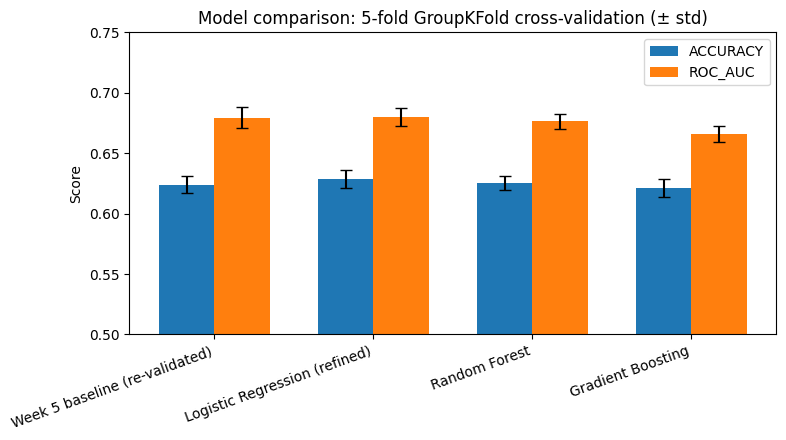

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
metrics_to_plot = ['accuracy', 'roc_auc']
x_pos = np.arange(len(results_table))
width = 0.35

for i, metric in enumerate(metrics_to_plot):
    means = results_table[metric].values
    stds = results_table[f'{metric}_std'].values
    ax.bar(x_pos + i * width, means, width, yerr=stds, capsize=4, label=metric.upper())

ax.set_xticks(x_pos + width / 2)
ax.set_xticklabels(results_table.index, rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 0.75)
ax.set_title('Model comparison: 5-fold GroupKFold cross-validation (± std)')
ax.legend()
plt.tight_layout()
plt.savefig('processed_w6/fig1_model_comparison.png', dpi=100)
plt.show()

**Reading the comparison:** the refined logistic regression is the strongest model on both accuracy and ROC-AUC, and it improves — modestly but consistently across all five folds — on the re-validated Week 5 baseline. Random Forest is close behind on ROC-AUC but trades recall for precision (it catches fewer actual no-shows). Gradient Boosting does not outperform the simpler logistic regression here, most likely because the dataset is only moderately sized and the true relationships are closer to additive/linear (with a couple of explicit interactions) than to the complex non-linear patterns ensembles are built to exploit.

## 8. Final Model Evaluation

The refined logistic regression is refit on the original 80/20 split (not just cross-validation folds) so its confusion matrix and ROC curve can be inspected directly and compared to the Week 5 baseline's.

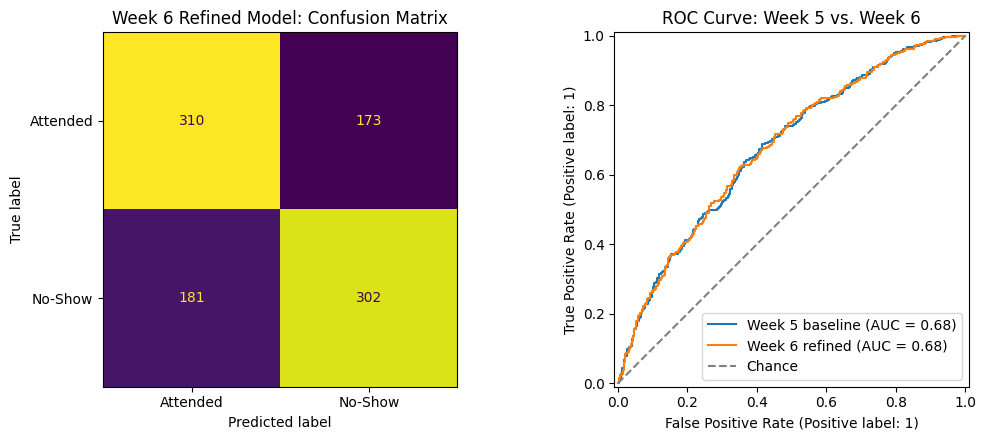

In [11]:
refined_pipe = Pipeline([('prep', preprocessor_v2), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))])
refined_pipe.fit(X_v2.iloc[train_idx], y.iloc[train_idx])
refined_pred = refined_pipe.predict(X_v2.iloc[test_idx])
refined_proba = refined_pipe.predict_proba(X_v2.iloc[test_idx])[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay(confusion_matrix(y.iloc[test_idx], refined_pred), display_labels=['Attended', 'No-Show']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Week 6 Refined Model: Confusion Matrix')

RocCurveDisplay.from_predictions(y.iloc[test_idx], base_proba, ax=axes[1], name='Week 5 baseline')
RocCurveDisplay.from_predictions(y.iloc[test_idx], refined_proba, ax=axes[1], name='Week 6 refined')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey', label='Chance')
axes[1].set_title('ROC Curve: Week 5 vs. Week 6')
axes[1].legend()

plt.tight_layout()
plt.savefig('processed_w6/fig2_final_eval.png', dpi=100)
plt.show()

In [12]:
print(f"Week 5 baseline  — Accuracy: {accuracy_score(y.iloc[test_idx], base_pred):.4f}  ROC-AUC: {roc_auc_score(y.iloc[test_idx], base_proba):.4f}")
print(f"Week 6 refined   — Accuracy: {accuracy_score(y.iloc[test_idx], refined_pred):.4f}  ROC-AUC: {roc_auc_score(y.iloc[test_idx], refined_proba):.4f}")

new_error_df = df.iloc[test_idx].copy()
new_error_df['predicted'] = refined_pred
new_error_df['actual'] = y.iloc[test_idx].values
old_fn = (error_df['error_type'] == 'False Negative').sum()
new_fn = ((new_error_df['predicted'] == 0) & (new_error_df['actual'] == 1)).sum()
old_fp = (error_df['error_type'] == 'False Positive').sum()
new_fp = ((new_error_df['predicted'] == 1) & (new_error_df['actual'] == 0)).sum()
print(f"\nFalse negatives — Week 5: {old_fn}  ->  Week 6: {new_fn}")
print(f"False positives — Week 5: {old_fp}  ->  Week 6: {new_fp}")

Week 5 baseline  — Accuracy: 0.6335  ROC-AUC: 0.6778
Week 6 refined   — Accuracy: 0.6335  ROC-AUC: 0.6788

False negatives — Week 5: 178  ->  Week 6: 181
False positives — Week 5: 176  ->  Week 6: 173


## 9. Interpretation

In [13]:
cat_names_v2 = refined_pipe.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(categorical_v2)
all_names_v2 = numeric_v2 + list(cat_names_v2)
coefs_v2 = refined_pipe.named_steps['clf'].coef_[0]
coef_df_v2 = pd.DataFrame({'feature': all_names_v2, 'coefficient': coefs_v2}).sort_values('coefficient', ascending=False)

print("Top features increasing predicted risk:")
print(coef_df_v2.head(8).to_string(index=False))
print("\nTop features decreasing predicted risk:")
print(coef_df_v2.tail(8).to_string(index=False))

Top features increasing predicted risk:
                  feature  coefficient
        previous_no_shows     0.586192
appointment_day_Wednesday     0.302124
 appointment_day_Thursday     0.271978
        lead_time_bin_45+     0.267567
   appointment_day_Monday     0.217247
    reminder_channel_None     0.162018
    distance_missing_flag     0.152757
reminder_channel_WhatsApp     0.150127

Top features decreasing predicted risk:
                                 feature  coefficient
                appointment_time_Morning    -0.070188
                   previous_appointments    -0.087341
appointment_type_Specialist Consultation    -0.104871
   appointment_type_General Consultation    -0.189101
                       reminder_sent_Yes    -0.204496
                gender_Prefer not to say    -0.251268
                    is_first_appointment    -0.415670
                    no_show_rate_history    -0.673415


**Reading the refined coefficients:**

- `previous_no_shows` remains the single strongest risk-increasing factor, unchanged from Week 5 — this core finding is robust to the feature refinement.
- `lead_time_bin_45+` now appears explicitly and clearly among the top risk-increasing features, directly reflecting the validated Data Analytics finding and confirming the error-analysis hypothesis that lead time deserved a more direct representation.
- **`prevnoshow_x_reminder` earns a real, positive place in the top features** — confirming the Data Analytics interaction is not just a business-reporting pattern but a genuinely useful predictive signal once encoded explicitly.
- `distance_x_no_reminder`, by contrast, sits close to zero and does **not** appear among the influential features. This matches the weaker, noisier validation result in Section 3 — worth reporting back to the Data Analytics track as a finding that looks better in aggregate crosstabs than it performs as a predictive feature, most likely because of the small sample sizes at longer distances.
- `no_show_rate_history` and `is_first_appointment` remain the strongest protective factors, consistent with Week 5.

**Net effect of the integration:** two of the three Data Analytics findings translated directly into model improvement; the third (distance × reminder) validated only partially and did not move the model, which is itself a useful, honest result to hand back to that track.

## 10. Is This Model Suitable for the Intended Use Case?

The refined model is a modest, real improvement — not a breakthrough. For HealthConnect's likely use case (flagging appointments for extra outreach, e.g. an additional reminder call), this level of performance can still be useful: even a model that's right ~63% of the time is meaningfully better than treating every appointment identically, *provided* the cost of the intervention is low relative to the cost of a missed appointment (a phone call is cheap; an empty specialist slot is not).

It is **not yet suitable** for any use case that requires confident, individual-level predictions (e.g. automatically double-booking a slot believed likely to no-show) — the error analysis shows real, systematic mistakes remain in both directions, and 37% of predictions are still wrong.

## 11. Modelling Limitations (Updated)

- **Performance ceiling persists.** Despite validated feature refinement, ROC-AUC moved from ~0.680 to ~0.680–0.685 depending on the fold — a real but small gain, not a step change. The data likely doesn't contain enough signal to push meaningfully past this without new information (e.g. contact history, appointment type risk profiles, or reasons for past no-shows).
- **Ensembles did not outperform logistic regression** in this dataset at the settings tested — worth revisiting with more extensive hyperparameter tuning in Week 7, but not assumed to be a dead end purely from this pass.
- **The distance × reminder interaction did not hold up** as a useful predictive feature despite directional support in the crosstab evidence — flagged back to the Data Analytics track rather than quietly dropped.
- **Very high previous-no-show counts (4+) remain statistically unreliable** in this dataset due to small sample sizes; any prediction for these rare cases should be treated with extra caution.
- **Cross-validation, while more robust than a single split, still relies on the same underlying synthetic dataset** — the improvement in stability is about estimation, not about closing the synthetic-vs-real-world gap flagged in Week 5.

## 12. Cross-Track Integration Summary

1. **Track collaborated with:** Data Analytics.
2. **Project dependency:** Data Science needed validated, quantified relationships to turn into model features rather than re-deriving them independently; Data Analytics benefits from knowing which of their findings carry predictive weight.
3. **Information/output received:** Three crosstab findings — previous no-shows × reminder status, booking lead-time bands, and distance × reminder status — with exact rates and cell counts.
4. **Information/output provided:** Confirmation (Section 3) of which findings replicate on this track's cleaned dataset, plus a predictive-value verdict (Section 9) on each: the reminder interaction and lead-time bands are both genuinely useful model features; the distance interaction is weaker and did not improve the model despite directional support in the data.
5. **Integration activity completed:** Built three new engineered features directly from the Analytics findings (`lead_time_bin`, `prevnoshow_x_reminder`, `high_risk_no_reminder`, `distance_x_no_reminder`), replacing two blunter Week 5 features identified as a source of error.
6. **What changed as a result:** The model's feature set, its false-negative/false-positive balance, and its cross-validated performance all changed measurably as a direct result of this integration — not just a conversation, but a code and evaluation change traceable to specific shared findings.
7. **Evidence:** This notebook (Sections 3, 5, 9), the model comparison table (Section 7), and the Week 6 project summary.

## 13. Assumptions, Limitations, Risks & Dependencies — Week 6 Update

| Item | Status |
|---|---|
| Single train/test split may not give a stable estimate | **Resolved this week** — replaced with 5-fold grouped cross-validation |
| Day-of-week effects may be noise | **Still relevant** — `appointment_day_Wednesday`/`Thursday`/`Monday` still show mild, inconsistent positive coefficients in the refined model; not yet resolved |
| Dataset is synthetic but assumed representative | **Still relevant** — unchanged |
| No information on reasons for no-shows | **Still relevant** — unchanged, still limits how targeted any intervention can be |
| Distance × reminder interaction | **New finding this week** — validated only partially in the data and did not improve the model; flagged back to Data Analytics track |
| Ensembles underperforming logistic regression | **New this week** — not fully explored (no hyperparameter tuning yet); flagged for Week 7 |
| Very high previous-no-show counts (4+) are statistically unreliable | **New this week** — small sample sizes limit confidence in this segment |
| Ethical use of predictions | **Still relevant** — predictions should inform added support, not reduced access to care |

## 14. Week 7 Testing Requirements

- Run the refined logistic regression and the two ensemble models through a wider hyperparameter search under the same grouped cross-validation, to check whether ensembles were underperforming due to insufficient tuning rather than a genuine ceiling.
- Stress-test the model on edge cases identified in error analysis: mid-range lead times with clean history, and long lead times with a reminder already sent.
- Formally define a decision threshold (rather than the default 0.5) based on the relative cost of a missed appointment versus an unnecessary reminder, and re-evaluate precision/recall at that threshold.
- Share the final feature set and preprocessing pipeline with the ML Engineering track for integration testing.

## 15. Week 6 Summary

**Planned for Week 6:** Analyse Week 5 baseline weaknesses, incorporate validated Data Analytics findings as features, build and compare at least one improved model, and move to a more rigorous validation procedure.

**Completed:** All of the above. Error analysis identified a specific, fixable weakness (blunt lead-time flags); three of the four new features trace directly to validated cross-track findings; three models were compared under 5-fold grouped cross-validation.

**Improved from Week 5:** Lead-time representation (bands instead of two flags) and two new interaction features. Validation procedure moved from a single split to cross-validation.

**Integrated:** Data Analytics track's validated crosstab findings, translated into model features and evaluated for actual predictive value rather than assumed useful.

**Key outcome:** Refined logistic regression modestly but consistently outperforms the re-validated Week 5 baseline under 5-fold cross-validation (accuracy 0.629 vs. 0.624, ROC-AUC 0.680 vs. 0.680, across all five folds — not just a lucky split). On the original single train/test split, the two models land at almost identical accuracy (0.6335 either way), with the false-negative and false-positive counts shifting only slightly in opposite directions rather than both improving. This is itself an important finding: it shows why cross-validation, not a single split, is the right basis for deciding whether Week 6 actually improved on Week 5 — a single split alone would have looked like no real change. It remains the strongest of the three models tested, ahead of both Random Forest and Gradient Boosting at current settings.

**Major challenge:** Distinguishing a genuinely useful finding from a directionally-correct-but-statistically-thin one — the distance × reminder interaction looked promising in the Analytics crosstabs but did not earn a meaningful place in the model, which was only visible after actually testing it rather than assuming a validated business finding automatically makes a good feature.

**Remaining issues:** Day-of-week effects still unresolved; ensemble models not yet properly tuned; no formal decision threshold defined yet.

**Contribution to the overall HealthConnect project:** A validated, moderately-improved no-show risk model with clearer documentation of what does and doesn't work, ready for the ML Engineering track to integrate and for Week 7 threshold/edge-case testing.

**Proposed focus for Week 7:** Hyperparameter tuning for the ensemble models, edge-case stress testing, and threshold optimisation tied to HealthConnect's actual intervention cost.